# Phase 5 — Stress Tests

Re-run the optimization engine under 3 stress scenarios and report how the optimal allocation and risk metrics shift.

1. **European winter demand shock**: TTF scenario prices x1.6.
2. **Asian demand surge**: JKM scenario prices x1.5.
3. **Shipping disruption**: freight day-rates x2.0 *and* the two chokepoint-dependent routes are rerouted around the disruption: QATAR->EUROPE gains +9.5 days (Suez avoidance via the Cape of Good Hope), US_GC->ASIA gains +15 days (Panama Canal congestion/wait, consistent with 2023 drought disruption).

`network_config.py` adds a **take-or-pay floor** per origin (`min_supply_cargoes_per_month`: US_GC 3.0, Qatar 7.0, Australia 4.0, out of their respective capacities of 8/12/7) -- both LP variants now enforce it as a lower bound alongside the usual capacity ceilings.

**Risk metrics**: mean/std , worst-case shortfall (`(mean - min) / mean`), VaR/CVaR, and cargo utilization.

In [1]:
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "../src")
from netback import CostAssumptions
from network_config import ORIGINS, VESSEL, with_route_overrides
from optimization import (
    capacity_utilization,
    evaluate_portfolio,
    portfolio_stats,
    scenario_netbacks,
    solve_cvar_lp,
    solve_ev_lp,
)
from simulator import HubParams, simulate_paths

## Baseline scenarios

In [2]:
with open("../data/processed/calibration/hub_params.json") as f:
    calibration = json.load(f)
hub_order = calibration["correlation"]["hub_order"]
corr_matrix = calibration["correlation"]["matrix"]
all_params = [HubParams(**calibration["primary"][name]) for name in hub_order]

with open("../data/processed/combined/monthly_aligned.csv") as f:
    rows = list(csv.DictReader(f))
latest = rows[-1]
start_prices = {
    "HENRY_HUB": float(latest["henry_hub"]), "TTF": float(latest["ttf"]), "JKM": float(latest["jkm"]),
    "FREIGHT_ATLANTIC": float(latest["freight_atlantic"]), "FREIGHT_PACIFIC": float(latest["freight_pacific"]),
}

N_SCENARIOS = 2000
paths = simulate_paths(all_params, corr_matrix, n_paths=N_SCENARIOS, n_steps=1, start_prices=start_prices, seed=7)

baseline_prices = [
    {"HENRY_HUB": paths["HENRY_HUB"][i, -1], "TTF": paths["TTF"][i, -1], "JKM": paths["JKM"][i, -1]}
    for i in range(N_SCENARIOS)
]
baseline_freight = [
    {"FREIGHT_ATLANTIC": paths["FREIGHT_ATLANTIC"][i, -1], "FREIGHT_PACIFIC": paths["FREIGHT_PACIFIC"][i, -1]}
    for i in range(N_SCENARIOS)
]
print(f"{N_SCENARIOS} baseline scenarios (same seed as Phase 3, so directly comparable)")

2000 baseline scenarios (same seed as Phase 3, so directly comparable)


## Define the 3 stress scenarios

In [3]:
def shock(scenario_list, hub, multiplier):
    return [{**s, hub: s[hub] * multiplier} for s in scenario_list]


eu_winter_prices = shock(baseline_prices, "TTF", 1.6)
asia_surge_prices = shock(baseline_prices, "JKM", 1.5)

disruption_freight = shock(shock(baseline_freight, "FREIGHT_ATLANTIC", 2.0), "FREIGHT_PACIFIC", 2.0)
disruption_routes = with_route_overrides({
    ("QATAR", "EUROPE"): 9 + 9.5,   # Cape reroute avoiding Suez -- documented figure from Phase 0 research
    ("US_GC", "ASIA"): 22 + 15,     # Panama Canal congestion/wait, consistent with the 2023 drought disruption
})

scenarios = {
    "baseline": (baseline_prices, baseline_freight, None),
    "EU winter shock (TTF x1.6)": (eu_winter_prices, baseline_freight, None),
    "Asia demand surge (JKM x1.5)": (asia_surge_prices, baseline_freight, None),
    "Shipping disruption (freight x2, reroutes)": (baseline_prices, disruption_freight, disruption_routes),
}
for name, (p, f, r) in scenarios.items():
    print(f"{name}: TTF mean={np.mean([s['TTF'] for s in p]):.1f}  JKM mean={np.mean([s['JKM'] for s in p]):.1f}  "
          f"freight_atl mean={np.mean([s['FREIGHT_ATLANTIC'] for s in f]):,.0f}")

baseline: TTF mean=54.4  JKM mean=19.4  freight_atl mean=41,054
EU winter shock (TTF x1.6): TTF mean=87.0  JKM mean=19.4  freight_atl mean=41,054
Asia demand surge (JKM x1.5): TTF mean=54.4  JKM mean=29.2  freight_atl mean=41,054
Shipping disruption (freight x2, reroutes): TTF mean=54.4  JKM mean=19.4  freight_atl mean=82,109


## Re-optimize under each scenario

In [4]:
cargo_size = VESSEL["cargo_size_mmbtu"]
RISK_LAMBDA = 2.0  # same as Phase 3, for direct comparability

results = {}
for name, (prices, freight, routes) in scenarios.items():
    kwargs = {"routes": routes} if routes is not None else {}
    netbacks = scenario_netbacks(prices, freight, **kwargs)
    ev_alloc, _, ev_status = solve_ev_lp(netbacks, **kwargs)
    risk_alloc, _, risk_status = solve_cvar_lp(netbacks, risk_lambda=RISK_LAMBDA, **kwargs)
    assert ev_status == "Optimal" and risk_status == "Optimal", f"{name}: EV={ev_status}, risk={risk_status}"

    ev_pv = evaluate_portfolio(ev_alloc, netbacks)
    results[name] = {
        "ev_allocation": ev_alloc,
        "risk_allocation": risk_alloc,
        "ev_stats": portfolio_stats(ev_pv, cargo_size_mmbtu=cargo_size),
        "ev_portfolio_values": ev_pv * cargo_size,
        "utilization": capacity_utilization(ev_alloc, **kwargs),
    }

print("Solved EV + risk-aware LP under all 4 scenarios (baseline + 3 stress)")

Solved EV + risk-aware LP under all 4 scenarios (baseline + 3 stress)


## Allocation shifts (expected-value LP)

In [5]:
alloc_df = pd.DataFrame({name: r["ev_allocation"] for name, r in results.items()}).fillna(0).round(2)
alloc_df.index = [f"{o}->{d}" for o, d in alloc_df.index]
alloc_df

,baseline,EU winter shock (TTF x1.6),Asia demand surge (JKM x1.5),"Shipping disruption (freight x2, reroutes)"
US_GC->EUROPE,0.00,0.00,0.00,0.62
US_GC->ASIA,0.00,0.00,0.00,0.00
US_GC->US_DOMESTIC,8.00,8.00,8.00,7.38
QATAR->EUROPE,0.62,11.05,0.62,0.00
QATAR->ASIA,8.00,0.00,8.00,8.00
AUSTRALIA->ASIA,7.00,4.00,7.00,7.00
AUSTRALIA->EUROPE,0.00,0.00,0.00,0.00


**Notable finding**: under the EU winter shock, Australia's liquefaction utilization drops from 100% to **57%** -- exactly its 4.0-cargo take-or-pay floor.

In [6]:
risk_alloc_df = pd.DataFrame({name: r["risk_allocation"] for name, r in results.items()}).fillna(0).round(2)
risk_alloc_df.index = [f"{o}->{d}" for o, d in risk_alloc_df.index]
ev_australia = alloc_df.loc["AUSTRALIA->ASIA", "EU winter shock (TTF x1.6)"] + alloc_df.loc["AUSTRALIA->EUROPE", "EU winter shock (TTF x1.6)"]
risk_australia = risk_alloc_df.loc["AUSTRALIA->ASIA", "EU winter shock (TTF x1.6)"] + risk_alloc_df.loc["AUSTRALIA->EUROPE", "EU winter shock (TTF x1.6)"]
print("Risk-aware LP allocation under the EU winter shock:")
print(risk_alloc_df["EU winter shock (TTF x1.6)"].to_string())
print(f"\nAustralia total: {risk_australia:.2f} cargoes (risk-aware) vs. {ev_australia:.2f} cargoes (EV LP) -- "
      f"both sit exactly at the 4.0-cargo take-or-pay floor.")

Risk-aware LP allocation under the EU winter shock:
US_GC->EUROPE          0.00
US_GC->ASIA            0.00
US_GC->US_DOMESTIC     8.00
QATAR->EUROPE         11.05
QATAR->ASIA            0.00
AUSTRALIA->ASIA        4.00
AUSTRALIA->EUROPE      0.00

Australia total: 4.00 cargoes (risk-aware) vs. 4.00 cargoes (EV LP) -- both sit exactly at the 4.0-cargo take-or-pay floor.


## Risk metrics by scenario

In [7]:
stats_rows = {}
for name, r in results.items():
    s = r["ev_stats"]
    stats_rows[name] = {
        "mean": f"${s['mean']:,.0f}",
        "std": f"${s['std']:,.0f}",
        "VaR95": f"${s['VaR95']:,.0f}",
        "CVaR95": f"${s['CVaR95']:,.0f}",
        "sharpe_like": f"{s['sharpe_like']:.2f}",
        "worst_case_shortfall": f"{s['worst_case_shortfall_pct']:.0f}%",
        "vessel_fleet_util": f"{r['utilization']['vessel_fleet']:.0%}",
    }
pd.DataFrame(stats_rows).T

,mean,std,VaR95,CVaR95,sharpe_like,worst_case_shortfall,vessel_fleet_util
baseline,"$845,499,643","$177,546,144","$581,825,391","$537,952,736",4.76,54%,100%
EU winter shock (TTF x1.6),"$1,161,834,917","$192,623,905","$873,962,865","$815,390,931",6.03,46%,100%
Asia demand surge (JKM x1.5),"$1,282,955,653","$262,957,899","$893,989,172","$827,102,644",4.88,52%,100%
"Shipping disruption (freight x2, reroutes)","$829,251,676","$177,434,810","$565,951,773","$521,681,589",4.67,55%,100%


## Storage/liquefaction utilization by scenario

In [8]:
util_rows = {}
for name, r in results.items():
    row = {}
    for origin, pct in r["utilization"]["liquefaction_by_origin"].items():
        row[f"liq:{origin}"] = f"{pct:.0%}"
    for dest, pct in r["utilization"]["storage_by_destination"].items():
        row[f"stor:{dest}"] = f"{pct:.0%}"
    util_rows[name] = row
pd.DataFrame(util_rows).T

,liq:US_GC,liq:QATAR,liq:AUSTRALIA,stor:EUROPE,stor:ASIA,stor:US_DOMESTIC
baseline,100%,72%,100%,4%,100%,40%
EU winter shock (TTF x1.6),100%,92%,57%,74%,27%,40%
Asia demand surge (JKM x1.5),100%,72%,100%,4%,100%,40%
"Shipping disruption (freight x2, reroutes)",100%,67%,100%,4%,100%,37%


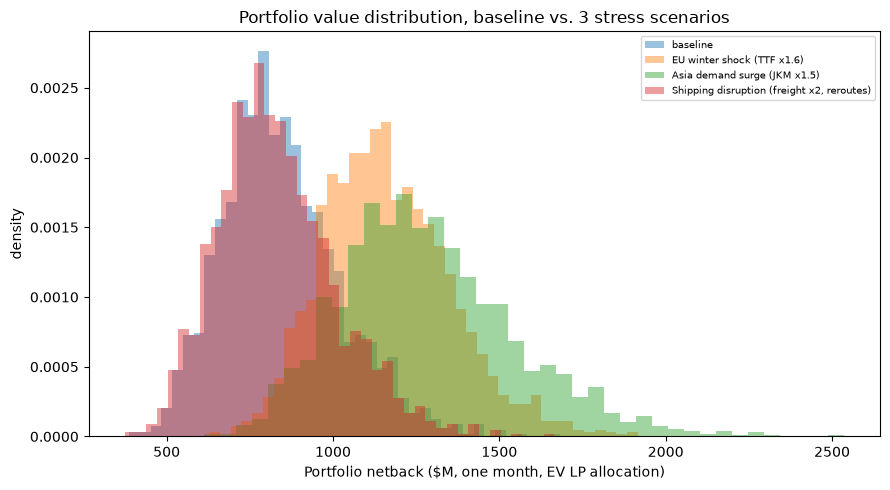

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.hist(r["ev_portfolio_values"] / 1e6, bins=40, alpha=0.45, label=name, density=True)
ax.set_xlabel("Portfolio netback ($M, one month, EV LP allocation)")
ax.set_ylabel("density")
ax.set_title("Portfolio value distribution, baseline vs. 3 stress scenarios")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Reading the results

- **EU winter shock** raises TTF, and the EV LP's response is more dramatic than a simple reallocation: Qatar's exports concentrate almost entirely in Europe, consuming nearly the *entire* vessel fleet, and **Australia gets pushed down to exactly its 4.0-cargo take-or-pay floor** (57% liquefaction utilization, down from 100% in the baseline).

The risk-aware LP makes the identical choice on every route. CVaR penalizes portfolio-level tail risk, and here concentrating the *discretionary* fleet in Europe is both the highest-expected-value and lowest-tail-risk option, so there's no risk-return trade-off left to exploit. Portfolio-level risk-awareness isn't the same as diversification-by-construction.

- **Asia demand surge** reinforces the already-Asia-leaning baseline allocation.

- **Shipping disruption** is the one that changes *feasibility*, not just relative value: the vessel fleet constraint gets tighter still once Qatar->Europe and US_GC->Asia both need more vessel-days per cargo, on top of paying double the day-rate.
 
Long routes are penalised double and the allocation shifts toward whichever destination is cheapest to reach with the fleet that remains, and portfolio value falls even after re-optimizing (mean drops from $845M to $829M).

## Save

In [10]:
import os

os.makedirs("../data/processed/stress_tests", exist_ok=True)
alloc_df.to_csv("../data/processed/stress_tests/allocations.csv")
with open("../data/processed/stress_tests/risk_metrics.json", "w") as f:
    json.dump({name: r["ev_stats"] for name, r in results.items()}, f, indent=2)
with open("../data/processed/stress_tests/utilization.json", "w") as f:
    json.dump({name: r["utilization"] for name, r in results.items()}, f, indent=2)

print("Saved allocations.csv, risk_metrics.json, utilization.json to ../data/processed/stress_tests/")

Saved allocations.csv, risk_metrics.json, utilization.json to ../data/processed/stress_tests/
